In [11]:
import pandas as pd
# # Import the dataset
# df = pd.read_csv("../data/soc-redditHyperlinks-body.tsv", sep='\t')

# # Drop irrelevant columns
# df = df.drop(['POST_ID','PROPERTIES'], axis=1)

# # Save the dataframe to a new CSV file
# df.to_csv("../data/redditHyperlinks-column-filtered.csv", index=False)

# Load the updated Dataframe
df = pd.read_csv("../data/redditHyperlinks-column-filtered.csv")

# Display the updated DataFrame
print(len(df))
df.head()

286561


,SOURCE_SUBREDDIT,TARGET_SUBREDDIT,TIMESTAMP,LINK_SENTIMENT
0,leagueoflegends,teamredditteams,2013-12-31 16:39:58,1
1,theredlion,soccer,2013-12-31 18:18:37,-1
2,inlandempire,bikela,2014-01-01 14:54:35,1
3,nfl,cfb,2013-12-31 17:37:55,1
4,playmygame,gamedev,2014-01-01 02:51:13,1


# Create the graph
We create separate dictionaries for negative and positive edges. In the graph, there should not be duplicate edges. Therefore, we count how many negative and positive mentions there are from one subreddit to another and use this as the edge weight.

In [14]:
import networkx as nx
import json
from collections import defaultdict

# create separate dictionaries for negative and positive edges
positive = defaultdict(int)
negative = defaultdict(int)
for index, row in df.iterrows():
    # count number of mentions between subreddits
    if row['LINK_SENTIMENT'] == 1:
        positive[(row['SOURCE_SUBREDDIT'],row['TARGET_SUBREDDIT'])] += 1
    else:
        negative[(row['SOURCE_SUBREDDIT'],row['TARGET_SUBREDDIT'])] += 1

# create weighted list of edges based on number of mentions
positive_weighted_list=[(sub1,sub2,weight) for (sub1,sub2),weight in positive.items()]
negative_weighted_list=[(sub1,sub2,weight) for (sub1,sub2),weight in negative.items()]  

def create_graph(weighted_list, title):
    # create the graphs
    G=nx.DiGraph()
    G.add_weighted_edges_from(weighted_list)

    # save the graphs
    Json_data=nx.node_link_data(G)
    with open(f"../data/{title}_graph.json",'w') as file:
        json.dump(Json_data,file,indent=2) 
    
    return G

G_positive = create_graph(positive_weighted_list, "positive")
G_negative = create_graph(negative_weighted_list, "negative")

Now we would like to find communities in both graphs. FORKLAR SENERE

In [15]:
import netwulf as nw

def compute_communities(G,title):
    'Computes the communities and returns a data partition for netwulf visualization'

    partition=nx.community.louvain_communities(G)
   
    for i, community in enumerate(partition):
        for node in community:
            G.nodes[node]['group'] = i


    # save community partition
    json_data = nx.node_link_data(G)
    with open(f'../data/{title}_communities.json','w') as file:
        json.dump(json_data,file,indent=2)
    
    # convert graph to correct format for plotting
    graph_data_partition=nx.json_graph.node_link_data(G)
    graph_data_partition['links'] = graph_data_partition.pop('edges')
    return graph_data_partition

positive_partition=compute_communities(G_positive,'positive')
negative_partition=compute_communities(G_negative,'negative')

Now we visualize the graphs

In [ ]:
nw.visualize(positive_partition)

(None, None)

This is a very large graph. We clearly need to cut down on the number of subreddits

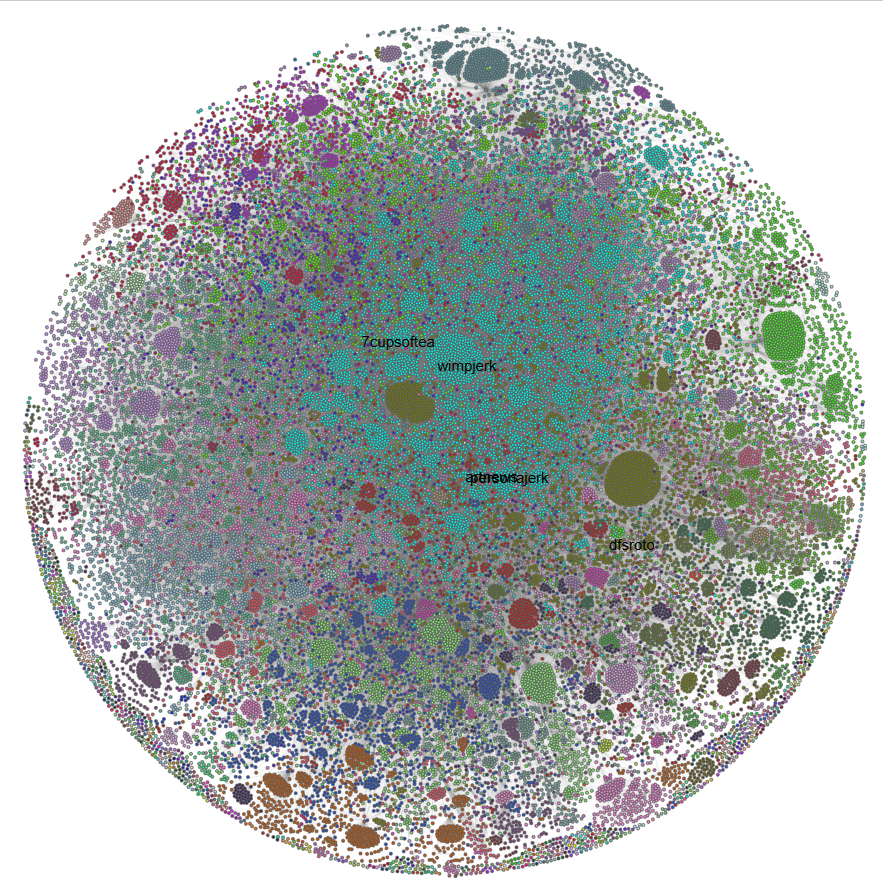

In [ ]:
nw.visualize(negative_partition, title='Negative Graph')